# Variable Distributions — Study Guide (with code)

This interactive notebook walks through probability distributions and why they matter for feature engineering and modeling.

**What you'll do here:**
- Understand probability distributions and their properties
- Compare normal and skewed distributions
- Visualize distributions with histograms and density-like views
- See how distribution shape influences imputation, scaling, and binning

> Tip: Run cells top-to-bottom. Plots use only `matplotlib`.

## 1) What is a probability distribution?
A probability distribution describes the likelihood of obtaining each possible value a random variable can take (e.g., human height values like 160 cm, 170 cm, 200 cm).
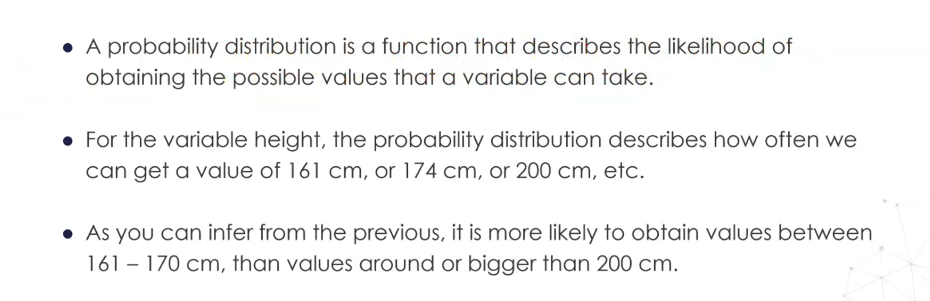


## 2) Properties of probability distributions
- Indicate the likelihood of an event/value.
- `p(x)` = probability the variable takes value `x`.
- Sum of probabilities over all possible values equals **1**.
- Each probability lies in **[0, 1]**.


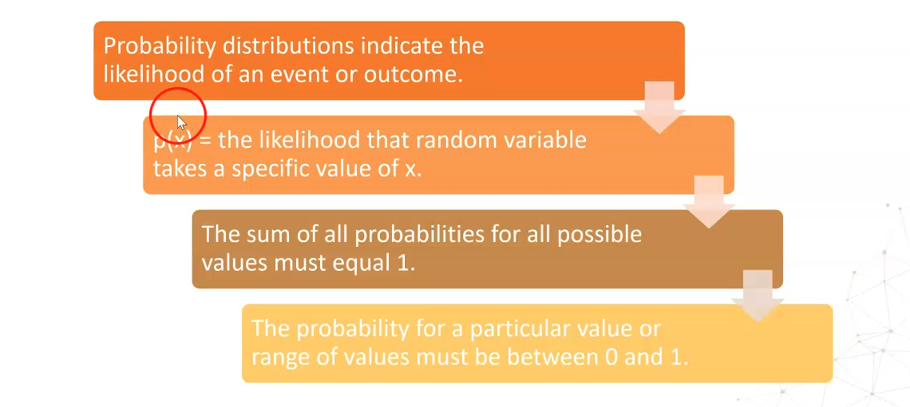

## 3) Types of probability distributions
- **Discrete** (e.g., Binomial, Poisson)
- **Continuous** (e.g., Normal/Gaussian, skewed)

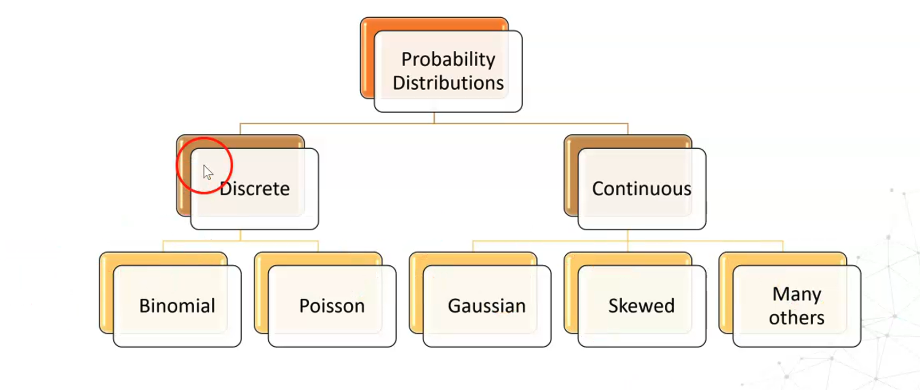

## 4) The Normal (Gaussian) distribution
- Symmetric, bell-shaped; many natural phenomena approximate it (height, blood pressure).
- Most observations concentrate around the center; probability tapers off equally on both sides.
- Extreme values in both tails are unlikely.

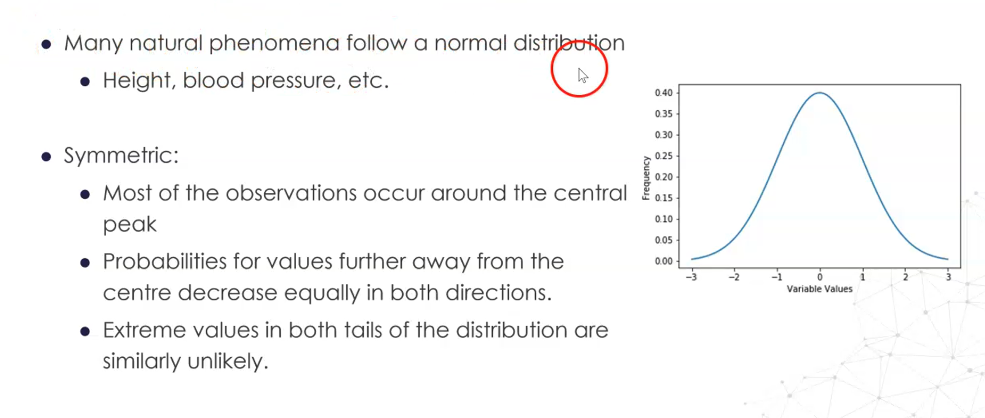

## 5) Skewed distributions
- **Left/negative skew**: long left tail.
- **Right/positive skew**: long right tail.

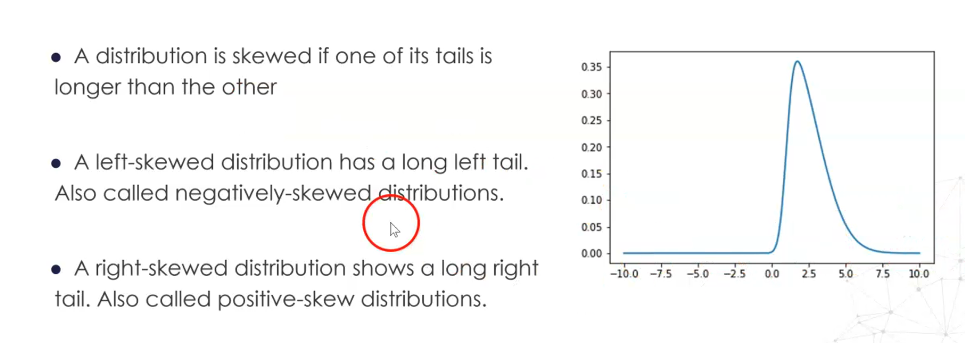

## 6) Gaussian vs. skewed — mean, median, mode
- Normal: mean ≈ median ≈ mode.
- Skewed: mean is pulled toward the tail; median is usually a better 'typical' value.

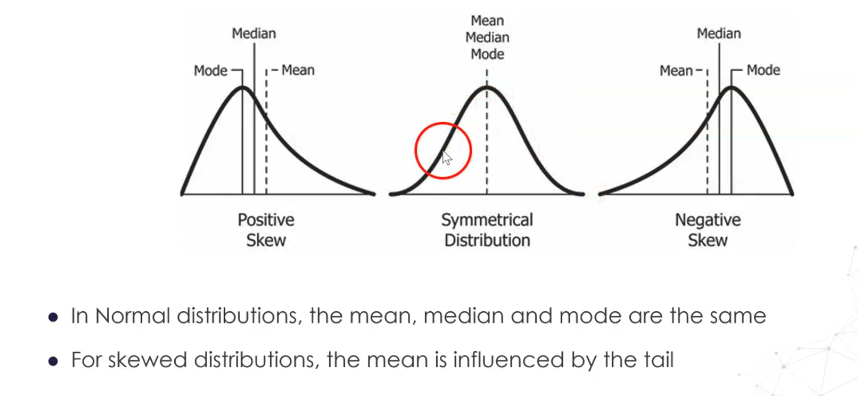

## 7) Distributions and model performance
- **Imputation**: Gaussian → mean; Skewed → median.
- **Scaling**: Gaussian → standardization; Skewed → robust scaling (median/quantiles).
- **Binning**: Gaussian → equal-width; Skewed → equal-frequency.

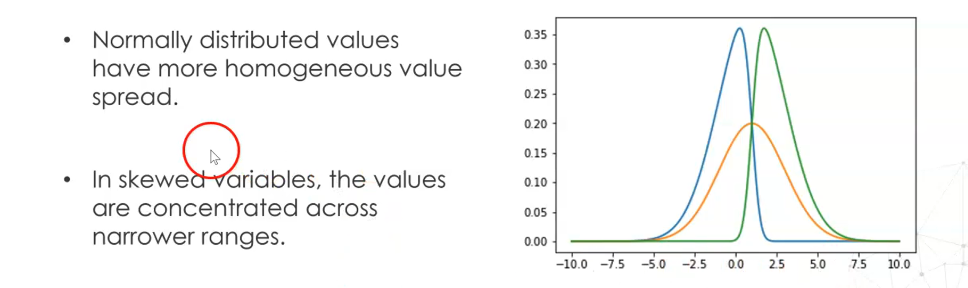

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
np.random.seed(42)
print('Ready!')

### 8) Visualize Normal vs. Skewed

In [ ]:
# Generate synthetic data: Normal and Skewed (Lognormal)
n = 5000
normal_data = np.random.normal(loc=0, scale=1, size=n)
skewed_data = np.random.lognormal(mean=0, sigma=0.8, size=n)

# Plot: Normal histogram
plt.figure()
plt.hist(normal_data, bins=40, density=True, alpha=0.7)
plt.title('Normal (Gaussian) — Histogram')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

# Plot: Skewed histogram
plt.figure()
plt.hist(skewed_data, bins=40, density=True, alpha=0.7)
plt.title('Right-Skewed (Lognormal) — Histogram')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

### 9) Compare Mean vs. Median vs. Mode (estimate)

In [ ]:
def quick_mode(x, bins=50):
    counts, edges = np.histogram(x, bins=bins)
    idx = np.argmax(counts)
    # return center of the modal bin
    return (edges[idx] + edges[idx+1]) / 2

for name, data in [('Normal', normal_data), ('Skewed', skewed_data)]:
    mean = np.mean(data)
    median = np.median(data)
    mode_est = quick_mode(data)
    print(f"{name}: mean={mean:.3f}, median={median:.3f}, mode≈{mode_est:.3f}")

### 10) Imputation: Mean vs Median on Skewed Data

In [ ]:
# Create a copy with missing values sprinkled in the skewed data
skewed_with_nan = skewed_data.copy()
mask = np.random.rand(skewed_with_nan.size) < 0.1  # 10% missing
skewed_with_nan[mask] = np.nan

mean_imputed = np.where(np.isnan(skewed_with_nan), np.nanmean(skewed_with_nan), skewed_with_nan)
median_imputed = np.where(np.isnan(skewed_with_nan), np.nanmedian(skewed_with_nan), skewed_with_nan)

plt.figure()
plt.hist(mean_imputed[~np.isnan(mean_imputed)], bins=40, alpha=0.7, density=True)
plt.title('Skewed: Histogram after **Mean** Imputation')
plt.xlabel('Value'); plt.ylabel('Density');
plt.show()

plt.figure()
plt.hist(median_imputed[~np.isnan(median_imputed)], bins=40, alpha=0.7, density=True)
plt.title('Skewed: Histogram after **Median** Imputation')
plt.xlabel('Value'); plt.ylabel('Density');
plt.show()

print('Imputation anchors — mean:', np.nanmean(skewed_with_nan), 'median:', np.nanmedian(skewed_with_nan))

### 11) Scaling: Standardization vs Robust Scaling

In [ ]:
# Compare scaling methods on skewed data
X = skewed_data.reshape(-1, 1)
std_scaled = StandardScaler().fit_transform(X)
rob_scaled = RobustScaler().fit_transform(X)

plt.figure()
plt.hist(std_scaled.ravel(), bins=40, density=True, alpha=0.7)
plt.title('Skewed data after StandardScaler (z-score)')
plt.xlabel('Scaled value'); plt.ylabel('Density');
plt.show()

plt.figure()
plt.hist(rob_scaled.ravel(), bins=40, density=True, alpha=0.7)
plt.title('Skewed data after RobustScaler (median/IQR)')
plt.xlabel('Scaled value'); plt.ylabel('Density');
plt.show()

### 12) Binning: Equal-Width vs Equal-Frequency

In [ ]:
data = skewed_data

# Equal-width bins
bins_eq_width = np.linspace(data.min(), data.max(), 8)
w_idx = np.digitize(data, bins_eq_width, right=False)

# Equal-frequency bins (quantiles)
quantiles = np.linspace(0, 1, 8)
bins_eq_freq = np.quantile(data, quantiles)
f_idx = np.digitize(data, bins_eq_freq, right=False)

plt.figure()
plt.hist(w_idx, bins=np.arange(1, 9)-0.5)
plt.title('Equal-Width Binning — Bin counts')
plt.xlabel('Bin'); plt.ylabel('Count');
plt.show()

plt.figure()
plt.hist(f_idx, bins=np.arange(1, 9)-0.5)
plt.title('Equal-Frequency Binning — Bin counts')
plt.xlabel('Bin'); plt.ylabel('Count');
plt.show()

## 13) Wrap-up
- Distribution shape guides practical choices: **imputation, scaling, binning, transforms**.
- For skewed variables, prefer **median-based** strategies and consider transformations.
- For near-Gaussian variables, **mean** and **standardization** are often appropriate.

Next step: explore **outliers**, which interact closely with skew and scaling choices.